<a href="https://colab.research.google.com/github/Yuvrajtakk/mnist-digit-recognizer/blob/main/DigiReco.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MNIST Digit Recognition — 7 Algorithm Comparison
### AI/ML Internship Project | Watsoo Express Pvt. Ltd.
**Intern:** Yuvraj Tak | B.Tech CSE-AI, Anand International College of Engineering  
**Mentor:** Ankit Gupta | Duration: June – August 2026

---

## Project Overview

This notebook implements a complete machine learning pipeline to classify handwritten digits (0–9) using the MNIST dataset. Seven algorithms are trained, evaluated, and compared side by side to identify which approach best suits digit classification.

The seven algorithms tested:
- Linear Regression *(baseline — regression tool on classification problem, included deliberately to demonstrate algorithm-problem mismatch)*
- Logistic Regression
- K-Nearest Neighbors (KNN)
- Decision Tree
- Random Forest
- Naive Bayes
- Support Vector Machine (SVM)

---

## Why These Seven?

These algorithms represent the full spectrum of classical machine learning approaches:

| Approach | Algorithms |
|---|---|
| Distance-based | KNN, SVM |
| Probability-based | Naive Bayes, Logistic Regression |
| Tree-based | Decision Tree, Random Forest |
| Regression-based | Linear Regression |

Each makes fundamentally different assumptions about the data. Running all seven on identical data and comparing their performance is what reveals which assumptions hold true for digit recognition.

---

## Pipeline Design Decisions

Every decision below was made deliberately before writing a single line of code:

**Dataset:** sklearn's built-in 8×8 MNIST (1,797 samples, 64 features per image). Chosen over the full 28×28 MNIST because algorithms like KNN and SVM become computationally impractical at 784 features — the curse of dimensionality creates uniform pairwise distances that make nearest-neighbor meaningless.

**Split:** 70% training, 30% testing with a fixed `random_state=42`. The fixed seed guarantees every algorithm sees the exact same test set — without this, accuracy comparisons across models are meaningless.

**Normalization:** StandardScaler applied once before all seven algorithms. Distance-based algorithms (KNN, SVM) require it. Tree-based algorithms (Decision Tree, Random Forest) are unaffected by scaling. Applying it universally simplifies the pipeline without changing any model's output.

**Primary evaluation metric:** Recall. In a real-world breakdown detection scenario, a missed failure (False Negative) is far more costly than a false alarm (False Positive). Recall measures exactly what proportion of real failures were caught.

---

## Section 1: Imports and Setup
### ANALOGY - Weapon layout

Before any data is loaded or any model is trained, Python needs to know which tools this project will use. This cell imports the complete toolkit — NumPy for array operations, Matplotlib for visualizations, and the relevant sklearn modules for data, splitting, scaling, and all seven algorithms.

All imports are declared upfront rather than scattered across cells. This is standard practice — anyone reading the notebook can see the full dependency list in one place.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## Section 2: Loading and Exploring the Dataset
### ANALOGY - opening the box of ingredients before cooking

Before training anything, I need to understand the data I am working with.
Shape, size, what the labels look like, what the pixel values look like.

Skipping exploration is the most common beginner mistake — building a pipeline
on data you never actually looked at, then wondering why results are strange.
I am answering four questions before touching any model:

- How many images exist?
- What does each image look like as numbers?
- What does each image look like visually?
- Are the digit classes balanced — or does one digit appear far more than others?

In [2]:
# Cell 2: Load the dataset and understand its structure

# load_digits() fetches the 8x8 MNIST dataset that lives inside sklearn
# We store everything it gives us inside a variable called 'digits'
digits = load_digits()

# digits is like a box containing multiple things inside it
# digits.data   → the actual pixel values (the input features)
# digits.target → the actual digit label for each image (0 through 9)
# digits.images → same pixel data but shaped as 8x8 grids instead of flat rows

# .shape tells you the dimensions of any array
# Think of it like asking "how many rows and columns does this table have?"
print("Dataset shape:", digits.data.shape)
# Output will be (1797, 64)
# 1797 = number of images
# 64   = number of pixel values per image (8 rows × 8 columns = 64)

print("Total images:", digits.data.shape[0])
# .shape[0] picks the first number from the shape
# shape[0] = rows = number of images

# shape[1] = columns = number of features per image
print("Features per image:", digits.data.shape[1])

print("Target labels (digit classes):", digits.target_names)
# target_names shows you every unique label in the dataset
# Should print: [0 1 2 3 4 5 6 7 8 9]

print("First image pixel values:")
print(digits.data[0])
# digits.data[0] picks the very first image (index 0)
# In Python, counting always starts from 0, not 1
# This prints 64 numbers between 0 and 16
# 0  = white pixel (no ink)
# 16 = black pixel (full ink)
# Numbers in between = grey pixels

print("Label of first image:", digits.target[0])
# This tells you what digit that first image actually is

Dataset shape: (1797, 64)
Total images: 1797
Features per image: 64
Target labels (digit classes): [0 1 2 3 4 5 6 7 8 9]
First image pixel values:
[ 0.  0.  5. 13.  9.  1.  0.  0.  0.  0. 13. 15. 10. 15.  5.  0.  0.  3.
 15.  2.  0. 11.  8.  0.  0.  4. 12.  0.  0.  8.  8.  0.  0.  5.  8.  0.
  0.  9.  8.  0.  0.  4. 11.  0.  1. 12.  7.  0.  0.  2. 14.  5. 10. 12.
  0.  0.  0.  0.  6. 13. 10.  0.  0.  0.]
Label of first image: 0


## Section 3: Visualizing the Data
### Analogy - Smelling and tasting the raw ingredients before cooking

64 numbers per image means nothing to the human eye.
Reshaping those numbers back into an 8×8 grid and rendering them as
grayscale images confirms the data loaded correctly and gives real
intuition about what the model is actually learning from.

I am displaying 25 sample images alongside their true labels.

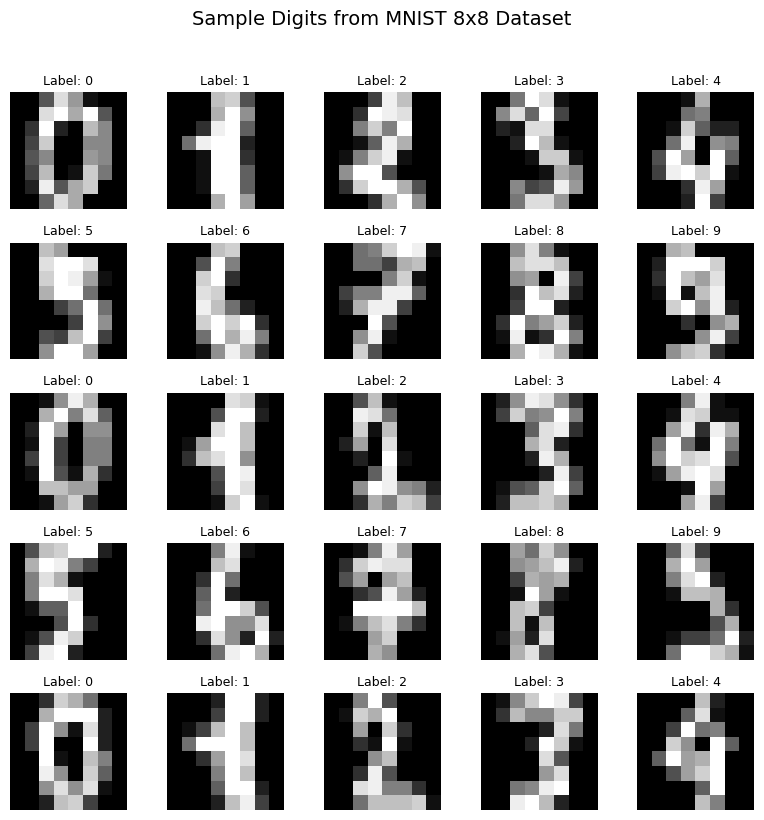

In [3]:
# Cell 3: Visualize 25 sample images from the dataset

# plt.subplots creates a grid of empty plots ready to be filled
# Think of it like creating a 5x5 table of empty picture frames on a wall
# (5, 5) = 5 rows, 5 columns = 25 frames total
# figsize=(8, 8) = total size of the wall in inches
fig, axes = plt.subplots(5, 5, figsize=(8, 8))

# suptitle puts one big title above the entire grid
# fontsize=14 controls how large that title text appears
fig.suptitle('Sample Digits from MNIST 8x8 Dataset', fontsize=14, y=1.02)

# axes right now is a 5x5 grid of plot objects — like a 2D array
# axes.flat converts that 5x5 grid into a simple flat list of 25 items
# enumerate() gives us two things at once: the position number AND the item
# so i = 0,1,2...24 and ax = each individual plot frame
for i, ax in enumerate(axes.flat):

    # digits.images[i] gives us image number i already shaped as 8x8 grid
    # imshow takes a 2D grid of numbers and draws it as an image
    # cmap='gray' means: low number (0) = black pixel, high number (16) = white pixel
    ax.imshow(digits.images[i], cmap='gray')

    # f-string syntax: f'some text {variable}'
    # the curly braces {} get replaced by the actual value of the variable
    # so if digits.target[0] is 0, this prints 'Label: 0'
    ax.set_title(f'Label: {digits.target[i]}', fontsize=9)

    # axis('off') hides the x and y axis numbers and tick marks
    # for images, those numbers are just pixel positions — meaningless clutter
    ax.axis('off')

# tight_layout automatically adjusts spacing between the 25 frames
# without it, titles from one row overlap into the images of the row above
plt.tight_layout()

# nothing appears on screen until you call plt.show()
# think of all the lines above as setting up the painting
# plt.show() is the moment you hang it on the wall
plt.show()